# Assignment 2 2AMM10 2023-2024

## Group: DL group 42
### Member 1: Dan Wu (2176963)
### Member 2: Anh Nguyên (1612131)
### Member 3: Hrvoje Miljak (1753517)

We need to install some specific libraries. The cell below installs torch_geometric for torch 2.6.0+cu124. In case the current version of torch is different, check [here](https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html) to see which versions (of both libraries) you should install. You might also need to install an old version of torch from [here](https://pytorch.org/get-started/previous-versions/)

**Note:** Do not install pyg_lib from the optional dependencies

In [1]:
%pip show torch

Name: torch
Version: 2.7.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /home/mil/anaconda3/envs/2AMM10/lib/python3.12/site-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-cufile-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvtx-cu12, setuptools, sympy, triton, typing-extensions
Required-by: torchaudio, torchvision
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install rdkit
%pip install torch_geometric
%pip install torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.7.0+cu128.html

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Looking in links: https://data.pyg.org/whl/torch-2.7.0+cu128.html
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pickle
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw, AllChem, rdchem
from rdkit import RDLogger
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_mean_pool
RDLogger.DisableLog('rdApp.*')
import matplotlib.pyplot as plt

In [4]:
with open('pos_data.pkl', 'rb') as f:
    pos_data = pickle.load(f)

with open('type_data.pkl', 'rb') as f:
    type_data = pickle.load(f)

with open('smiles.pkl', 'rb') as f:
    smiles_data = pickle.load(f)

data_split = np.load('data_split.npz')

train_idxes = data_split['train_idx']
test_idxes = data_split['test_idx']

formation_energy = np.load('formation_energy.npz')

fe = formation_energy['y'] # normalized formation energy
mu = formation_energy['mu']
std = formation_energy['sigma']

In [5]:
# shapes of lists
print("Length of data")
print(f"pos_data: {len(pos_data)}, type_data: {len(type_data)}, smiles: {len(smiles_data)}")
print("Idxes")
print(f"train: {len(train_idxes)}, test: {len(test_idxes)}, sum: {len(train_idxes) + len(test_idxes)}")

Length of data
pos_data: 129012, type_data: 129012, smiles: 129012
Idxes
train: 119012, test: 10000, sum: 129012


In [6]:
def at_number_to_atom_name(at_number):
    if at_number == 6:
        return 'C'
    elif at_number == 1:
        return 'H'
    elif at_number == 7:
        return 'N'
    elif at_number == 8:
        return 'O'
    elif at_number == 9:
        return 'F'
    elif at_number == 16:
        return 'S'
    else:
        return 'Unknown'

def inspect_structure(idx):
    smile = smiles_data[idx]
    pos = pos_data[idx]
    typ = type_data[idx]

    header = f"{'Atom':^5}│{'Number':^6}│{'x':^10}│{'y':^10}│{'z':^10}"
    line   = "─────┼──────┼──────────┼──────────┼──────────"
    print(header)
    print(line)

    for atom_num, (x, y, z) in zip(typ, pos):
        atom_sym = at_number_to_atom_name(atom_num)
        print(f"{atom_sym:^5}│{atom_num:^6}│{x:>10.3f}│{y:>10.3f}│{z:>10.3f}")
    print("")
    print("")
    print(f'SMILE: {smile}')
    print("")
    print("")
    print(f'Formation Energy: {fe[idx]*std + mu:.3f}')
    print(f'Formation Energy (normalized): {fe[idx]:.5f}')
    mol = Chem.MolFromSmiles(smile)
    if mol:
        # RDKit prefers 2‑D coordinates for nice depictions
        Chem.AllChem.Compute2DCoords(mol)
        img = Draw.MolToImage(mol, size=(300, 300))

        # Display with matplotlib (works both in notebooks and scripts)
        plt.figure(figsize=(3, 3))
        plt.axis('off')
        plt.imshow(img)
        plt.show()

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.013│     1.086│     0.008
  H  │  1   │     0.002│    -0.006│     0.002
  H  │  1   │     1.012│     1.464│     0.000
  H  │  1   │    -0.541│     1.447│    -0.877
  H  │  1   │    -0.524│     1.438│     0.906


SMILE: C


Formation Energy: -17.172
Formation Energy (normalized): 5.72327


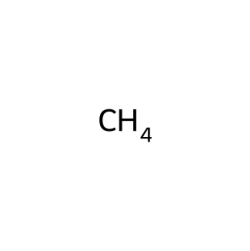

In [7]:
# methane
# Note how methane has a relatively high formation energy (compared to QM9)
# This correlates with lower thermodynamic stability and higher reactivity
# For example, methane readily burns in oxygen (CH₄ + 2O₂ → CO₂ + 2H₂O)
inspect_structure(0)

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │     0.004│     1.560│    -0.055
  C  │  6   │    -0.116│     0.079│     0.316
  C  │  6   │    -1.483│    -0.508│    -0.021
  C  │  6   │    -1.795│    -0.762│    -1.516
  O  │  8   │    -1.962│    -2.179│    -1.293
  C  │  6   │    -1.666│    -2.024│     0.096
  C  │  6   │    -0.862│    -3.043│     0.843
  C  │  6   │    -2.347│    -2.849│     1.138
  C  │  6   │    -2.805│    -2.247│     2.447
  H  │  1   │     0.994│     1.953│     0.194
  H  │  1   │    -0.154│     1.716│    -1.128
  H  │  1   │    -0.738│     2.164│     0.479
  H  │  1   │     0.659│    -0.501│    -0.200
  H  │  1   │     0.073│    -0.046│     1.390
  H  │  1   │    -2.271│     0.056│     0.488
  H  │  1   │    -2.709│    -0.301│    -1.908
  H  │  1   │    -0.964│    -0.555│    -2.204
  H  │  1   │    -0.564│    -3.932│     0.298
  H  │  1   │    -0.143│    -2.698│     1.580
  H  │  1   │    -2.993│    -3.624

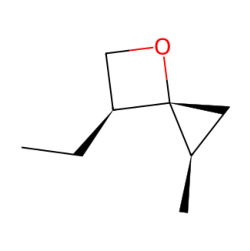

In [8]:
# random structure
inspect_structure(np.random.choice(range(len(smiles_data))))

## Task 1

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
class SMILESDataset(InMemoryDataset):
    def __init__(self, smiles, formation_energies):
        self.smiles = smiles
        self.formation_energies = formation_energies
        super(SMILESDataset, self).__init__('.')
        self.data, self.slices = self.collate([
            create_smiles_data(smile, formation_energy) for smile, formation_energy in zip(smiles, formation_energies)
        ])

def get_atom_features(atom):
    # 118 Atomic number
    atomic_number = atom.GetAtomicNum()
    one_hot_atomic = torch.zeros(118, dtype=torch.float)
    one_hot_atomic[atomic_number-1] = 1

    # 6 Degree
    degree = atom.GetDegree()
    one_hot_degree = torch.zeros(6, dtype=torch.float)
    one_hot_degree[min(degree, 5)] = 1

    # 1 Formal charge
    formal_charge = torch.tensor([max(-2, min(atom.GetFormalCharge(), 2))], dtype=torch.float)

    # 1 Aromatic
    aromatic = torch.tensor([int(atom.GetIsAromatic())], dtype=torch.float)

    # 5 Total Num Hs
    total_hs = atom.GetTotalNumHs()
    one_hot_total_hs = torch.zeros(5, dtype=torch.float)
    one_hot_total_hs[min(total_hs, 4)] = 1

    # 5 Hybridization
    hybridizations = [
        rdchem.HybridizationType.SP,
        rdchem.HybridizationType.SP2,
        rdchem.HybridizationType.SP3,
        rdchem.HybridizationType.SP3D,
        rdchem.HybridizationType.SP3D2
    ]
    hybrid = atom.GetHybridization()
    one_hot_hybrid = torch.zeros(len(hybridizations), dtype=torch.float)
    if hybrid in hybridizations:
        one_hot_hybrid[hybridizations.index(hybrid)] = 1

    # 3 Chirality
    chirality = atom.GetChiralTag()
    one_hot_chiral = torch.zeros(3, dtype=torch.float)
    if chirality == Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CW:
        one_hot_chiral[0] = 1
    elif chirality == Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CCW:
        one_hot_chiral[1] = 1
    else:
        one_hot_chiral[2] = 1  # No chirality


    # 139 total
    return torch.cat([one_hot_atomic, one_hot_degree, formal_charge, aromatic, one_hot_total_hs, one_hot_hybrid, one_hot_chiral])

def get_bond_features(bond):
    # 22 Bond types
    bond_types = [
        rdchem.BondType.UNSPECIFIED,
        rdchem.BondType.SINGLE,
        rdchem.BondType.DOUBLE,
        rdchem.BondType.TRIPLE,
        rdchem.BondType.QUADRUPLE,
        rdchem.BondType.QUINTUPLE,
        rdchem.BondType.HEXTUPLE,
        rdchem.BondType.ONEANDAHALF,
        rdchem.BondType.TWOANDAHALF,
        rdchem.BondType.THREEANDAHALF,
        rdchem.BondType.FOURANDAHALF,
        rdchem.BondType.FIVEANDAHALF,
        rdchem.BondType.AROMATIC,
        rdchem.BondType.IONIC,
        rdchem.BondType.HYDROGEN,
        rdchem.BondType.THREECENTER,
        rdchem.BondType.DATIVEONE,
        rdchem.BondType.DATIVE,
        rdchem.BondType.DATIVEL,
        rdchem.BondType.DATIVER,
        rdchem.BondType.OTHER,
        rdchem.BondType.ZERO
    ]
    bond_type = bond.GetBondType()
    one_hot_bond_type = torch.zeros(22, dtype=torch.float)
    if bond_type in bond_types:
        index = bond_types.index(bond_type)
        one_hot_bond_type[index] = 1

    # 1 Conjugated
    is_conjugated = torch.tensor([int(bond.GetIsConjugated())], dtype=torch.float)

    # 1 Ring
    is_in_ring = torch.tensor([int(bond.IsInRing())], dtype=torch.float)

    # 6 Stereo types
    stereo_types = [
        rdchem.BondStereo.STEREONONE,
        rdchem.BondStereo.STEREOANY,
        rdchem.BondStereo.STEREOZ,
        rdchem.BondStereo.STEREOE,
        rdchem.BondStereo.STEREOCIS,
        rdchem.BondStereo.STEREOTRANS,
    ]
    stereo = bond.GetStereo()
    one_hot_stereo = torch.zeros(len(stereo_types), dtype=torch.float)
    if stereo in stereo_types:
        one_hot_stereo[stereo_types.index(stereo)] = 1

    # 30 Total
    return torch.cat([one_hot_bond_type, is_conjugated, is_in_ring, one_hot_stereo])

def create_smiles_data(smile, formation_energy):
    mol = Chem.MolFromSmiles(smile)

    # Nodes are the atoms
    atom_features = [get_atom_features(atom) for atom in mol.GetAtoms()]
    node_features = torch.stack(atom_features, dim=0)
    
    # Edges are the bonds
    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        edge_index.append([bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()])
        edge_index.append([bond.GetEndAtomIdx(), bond.GetBeginAtomIdx()])

        bond_features = get_bond_features(bond)
        edge_attr.append(bond_features)
        edge_attr.append(bond_features)
    
    if len(edge_attr) == 0:
        edge_attr = torch.empty((0, 30), dtype=torch.float)
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.stack(edge_attr, dim=0)

    target = torch.tensor([formation_energy], dtype=torch.float)

    return Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr, y=target)
    

In [ ]:
smiles_train = [smiles_data[i] for i in train_idxes]
formation_energies_train = [fe[i] for i in train_idxes]

smiles_test = [smiles_data[i] for i in test_idxes]
formation_energies_test = [fe[i] for i in test_idxes]

train_smiles_data = SMILESDataset(smiles_train, formation_energies_train)
test_smiles_data = SMILESDataset(smiles_test, formation_energies_test)

In [76]:
# Print example of pos, type data
print("pos", pos_data[0])
print("type", type_data[0])


def create_graph_data(pos, typ, fe):
    # Convert to tensor
    pos_tensor = torch.tensor(pos, dtype=torch.float)
    type_tensor = torch.tensor(typ, dtype=torch.long)
    fe_tensor = torch.tensor(fe, dtype=torch.float)

    # Create edge index
    num_atoms = len(pos)
    edge_index = []
    for i in range(num_atoms):
        for j in range(num_atoms):
            if i != j:
                edge_index.append([i, j])    
    edge_index = torch.tensor(edge_index, dtype=torch.long)

    data = Data(x=type_tensor.unsqueeze(-1).float(), pos=pos_tensor, edge_index=edge_index, y=fe_tensor)
    return data

# Smile is string data, create a dataset for it
# def create_smiles_data(smile, fe):
#     mol = Chem.MolFromSmiles(smile)
#     if mol is None:
#         return None
#     AllChem.Compute2DCoords(mol)
#     pos = mol.GetConformer().GetPositions()
#     typ = [atom.GetAtomicNum() for atom in mol.GetAtoms()]
#     return Data(x=np.array(typ).reshape(-1, 1), pos=pos, y=fe)

# Create graph data for training and testing
train_graph_data = [create_graph_data(pos_data[i], type_data[i], fe[i]) for i in train_idxes]
test_graph_data = [create_graph_data(pos_data[i], type_data[i], fe[i]) for i in test_idxes]
# train_smiles_data = [create_smiles_data(smiles_data[i], fe[i]) for i in train_idxes]
# test_smiles_data = [create_smiles_data(smiles_data[i], fe[i]) for i in test_idxes]

# Create DataLoader for training and testing
graph_train_loader = DataLoader(train_graph_data, batch_size=32, shuffle=True)
graph_test_loader = DataLoader(test_graph_data, batch_size=32, shuffle=False)
smiles_train_loader = DataLoader(train_smiles_data, batch_size=32, shuffle=True)
smiles_test_loader = DataLoader(test_smiles_data, batch_size=32, shuffle=False)

print(train_graph_data[0])
print(train_smiles_data[0])

pos [[-1.2700e-02  1.0858e+00  8.0000e-03]
 [ 2.2000e-03 -6.0000e-03  2.0000e-03]
 [ 1.0117e+00  1.4638e+00  3.0000e-04]
 [-5.4080e-01  1.4475e+00 -8.7660e-01]
 [-5.2380e-01  1.4379e+00  9.0640e-01]]
type [6 1 1 1 1]
Data(x=[16, 1], edge_index=[240, 2], y=0.7149152159690857, pos=[16, 3])
Data(x=[9, 136], edge_index=[2, 22], edge_attr=[22, 30], y=[1])


In [77]:
class GNN(torch.nn.Module):
    def __init__(self, hidden_dim, node_dim, edge_dim):
        super(GNN, self).__init__()

        input = nn.Sequential(
            nn.Linear(node_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.conv1 = GINEConv(input, edge_dim=edge_dim)
        self.norm1 = nn.BatchNorm1d(hidden_dim)
        
        seq = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.conv2 = GINEConv(seq, edge_dim=edge_dim)
        self.norm2 = nn.BatchNorm1d(hidden_dim)
        self.dropout = nn.Dropout(p=0.2)
        self.lin = nn.Linear(hidden_dim, 1)
        
    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        edge_feature = data.edge_attr
        batch = data.batch

        x = self.conv1(x, edge_index, edge_feature)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index, edge_feature)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = global_mean_pool(x, batch)
        return self.lin(x).squeeze()

In [78]:
model  = GNN(hidden_dim=128, node_dim=139, edge_dim=30).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
mse = nn.MSELoss()

def train(model, loader):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = mse(out, batch.y.squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

def test(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            loss = mse(out, batch.y.squeeze())
            total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)

In [79]:
for epoch in range(1, 51):
    train_loss = train(model, smiles_train_loader)
    test_loss = test(model, smiles_test_loader)
    print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

RuntimeError: The size of tensor a (136) must match the size of tensor b (139) at non-singleton dimension 1

In [58]:
torch.save(model.state_dict(), 'SMILES_model.pth')

In [59]:
model.load_state_dict(torch.load('SMILES_model.pth'))
model.eval()

GNN(
  (conv1): GINEConv(nn=Sequential(
    (0): Linear(in_features=131, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (conv2): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (lin): Linear(in_features=128, out_features=1, bias=True)
)

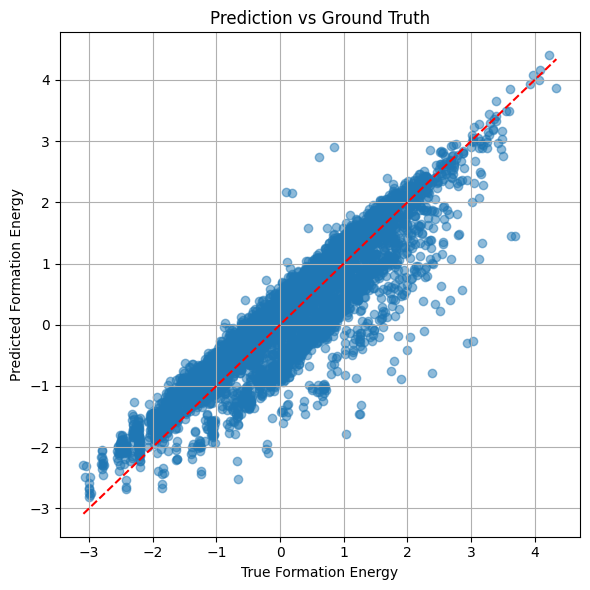

R² Score: 0.8459


In [69]:
y_true = []
y_pred = []

with torch.no_grad():
    for batch in smiles_test_loader:
        batch = batch.to(device)
        output = model(batch)
        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(output.cpu().numpy())

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.xlabel("True Formation Energy")
plt.ylabel("Predicted Formation Energy")
plt.title("Prediction vs Ground Truth")
plt.grid(True)
plt.tight_layout()
plt.show()

def r2_score_torch(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

r2 = r2_score_torch(torch.tensor(y_true), torch.tensor(y_pred)).item()
print(f"R² Score: {r2:.4f}")

In [ ]:
class Node_Embedding(nn.Module):
    def __init__ (self, node_feature_dim, node_embedding_dim):
        super(Node_Embedding, self).__init__()
        self.embedding_dim = node_embedding_dim
        self.feature_dim = node_feature_dim
        self.embedding = nn.Linear(node_feature_dim, node_embedding_dim)
    def forward(self, nodes):
        assert nodes.size(-1) == self.feature_dim, 'wrong input dimension of node features!'
        out = self.embedding(nodes)
        return out
    
# Message Passing Layer
class MP_layer(nn.Module):
    def __init__(self, hidden_dim, activation=nn.ReLU()):
        super(MP_layer, self).__init__()
        self.edge_network = nn.Sequential(nn.Linear(2*hidden_dim, hidden_dim),
                                          activation,
                                          nn.Linear(hidden_dim, hidden_dim),
                                          activation
                                          )
        
        self.node_network = nn.Sequential(nn.Linear(2*hidden_dim, hidden_dim),
                                          activation,
                                          nn.Linear(hidden_dim, hidden_dim),
                                          )
        
    def forward(self, input_to_layer):
        node_tensor, edge_idx_tensor = input_to_layer
        edge_messages_input = torch.concat([node_tensor[edge_idx_tensor[0,:]], node_tensor[edge_idx_tensor[1,:]]], dim=-1)
        edge_messages_output = self.edge_network(edge_messages_input)
        
        node_agg_messages = torch.zeros(node_tensor.size(0), node_tensor.size(1)).to(node_tensor.device)
        node_agg_messages = node_agg_messages.scatter_add_(
            dim=0, index=edge_idx_tensor[1].unsqueeze(-1).expand(-1, node_tensor.size(1)), src=edge_messages_output
        )

        node_out = self.node_network(torch.cat([node_tensor, node_agg_messages], dim=-1))

        return node_out, edge_idx_tensor
    
# GNN
class FormationEnergyGNN(nn.Module):
    def __init__(self, node_feat_dim, hidden_dim, activation=nn.ReLU(), num_layers=3):
        super(FormationEnergyGNN, self).__init__()
        self.node_to_emb = Node_Embedding(node_feat_dim, hidden_dim)
        self.forward_net = nn.Sequential(
            *[MP_layer(hidden_dim, activation) for i in range(num_layers)]
        )
        self.to_pred = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index, batch):
        x = self.node_to_emb(x)
        input_model = (x, edge_index)
        output_model = self.forward_net(input_model)
        x,_ = output_model
        
        out = torch.zeros(max(batch)+1, x.size(1)).to(x.device)
        idx_aggregate_graph = batch.unsqueeze(-1).expand(-1, x.size(1))

        out.scatter_add_(dim=0, index=idx_aggregate_graph, src=x)

        x = self.to_pred(out)
        return x
    
gnn = FormationEnergyGNN(node_feat_dim=14, hidden_dim=32, num_layers=5)

## Task 2

## Task 3

In [ ]:
def is_valid_smiles(smiles):
    if smiles is None:
        return False
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

def canonicalize(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToSmiles(mol, canonical=True)
        return 'None'
    except:
        return 'None'

In [ ]:
canonicalize("COO"), canonicalize("O(C)O")

In [ ]:
is_valid_smiles("COO"), is_valid_smiles("O(C)O"), is_valid_smiles("C##")